# Fake News Detection Dataset Analysis


**Project:** Fake News Detection 

### Objectives:
1. 📊 Analyze dataset statistics and quality
2. 🎯 Examine label distribution and class balance
3. 📏 Study text length patterns (characters, words, tokens)
4. ✍️ Analyze stylistic features
5. ...

---
## 1. Setup and Imports

In [16]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datetime import datetime
from tqdm import tqdm
import warnings
import json
from tqdm import tqdm
tqdm.pandas()
warnings.filterwarnings('ignore')

# NLP libraries
try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize, sent_tokenize
    from nltk.sentiment import SentimentIntensityAnalyzer
    
    # Download required NLTK data
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('vader_lexicon', quiet=True)
    
    NLTK_AVAILABLE = True
    print("✅ NLTK loaded successfully")
except Exception as e:
    NLTK_AVAILABLE = False
    print(f"⚠️  NLTK error: {e}")

# Tokenizer (optional - for transformer models)
try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print("✅ BERT tokenizer loaded successfully")
    TOKENIZER_AVAILABLE = True
except Exception as e:
    tokenizer = None
    TOKENIZER_AVAILABLE = False
    print(f"⚠️  Tokenizer not available: {e}")

# Visualization setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("\n" + "="*80)
print("🚀 Setup Complete!")
print("="*80)

✅ NLTK loaded successfully
✅ BERT tokenizer loaded successfully

🚀 Setup Complete!


---
## 2. Load Dataset

In [2]:
# Load your dataset
csv_path = "new_data_2.csv"  

print("📁 Loading dataset...")
df = pd.read_csv(csv_path)

print(f"\n✅ Dataset loaded successfully!")
print(f"   • Total articles: {len(df):,}")
print(f"   • Columns: {', '.join(df.columns)}")
print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\n📋 Sample Data:")
df.head()

📁 Loading dataset...

✅ Dataset loaded successfully!
   • Total articles: 7,329
   • Columns: source, date, label, category, text
   • Memory usage: 4.97 MB

📋 Sample Data:


,source,date,label,category,text
0,twitter,2025-11-16,3,nation,نفس العقلية اللي عند جماعة الحظيرة في الدزاير،...
1,twitter,2025-11-16,0,monde,خبر عاجل هادو هما ليكيبيات اللي كاليفياو لكاس ...
2,twitter,2025-11-16,1,societe,هادي تخصك إذا راك مقلق على الفيزا تاعك من غير ...
3,twitter,2025-11-16,2,nation,ياو الفايدة كامل راهي في الشرق، ماشي الغرب الل...
4,twitter,2025-11-16,0,monde,رسمي وعاجل هادو هما المنتخبات اللي تآهلو لكاس ...


---
## 3. Dataset Overview & Quality Check

In [42]:
print("="*80)
print("📊 DATASET OVERVIEW")
print("="*80)

# Basic info
print("\n📈 Dataset Information:")
print(df.info())

# Missing values
print("\n⚠️  Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate Records: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

# # Statistical summary
# print("\n📊 Statistical Summary:")
# df.describe(include='all')

📊 DATASET OVERVIEW

📈 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7329 entries, 0 to 7328
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   source       7329 non-null   object        
 1   date         4754 non-null   datetime64[ns]
 2   label        7329 non-null   int64         
 3   category     7329 non-null   object        
 4   text         7329 non-null   object        
 5   text_length  7329 non-null   int64         
 6   word_count   7329 non-null   int64         
 7   sentiment    7329 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 458.2+ KB
None

⚠️  Missing Values:
      Missing Count  Percentage
date           2575   35.134398

🔄 Duplicate Records: 0 (0.00%)


---
## 4. Label Distribution Analysis

🎯 LABEL DISTRIBUTION ANALYSIS

📊 Class Distribution:
            0:    4,397 (59.99%) █████████████████████████████
            3:    2,009 (27.41%) █████████████
            1:      796 (10.86%) █████
            2:      127 ( 1.73%) 

⚖️  Balance Ratio: 0.029
   ❌ Highly imbalanced


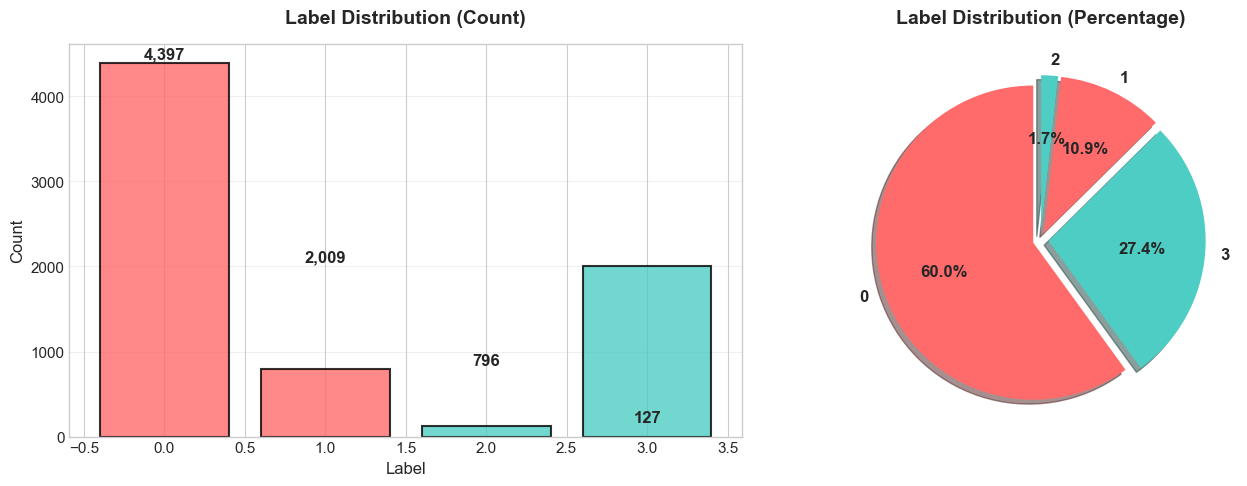

In [43]:
print("="*80)
print("🎯 LABEL DISTRIBUTION ANALYSIS")
print("="*80)

# Calculate distribution
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100
balance_ratio = label_counts.min() / label_counts.max()

# Display results
print("\n📊 Class Distribution:")
for label in label_counts.index:
    count = label_counts[label]
    pct = label_pct[label]
    bar = "█" * int(pct / 2)
    print(f"   {label:>10}: {count:>8,} ({pct:>5.2f}%) {bar}")

print(f"\n⚖️  Balance Ratio: {balance_ratio:.3f}")

# Interpretation
if balance_ratio > 0.7:
    print("   ✅ Dataset is well-balanced")
elif balance_ratio > 0.4:
    print("   ⚠️  Moderately imbalanced - consider class weights")
else:
    print("   ❌ Highly imbalanced")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF6B6B', '#4ECDC4']
ax1.bar(label_counts.index, label_counts.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_title('Label Distribution (Count)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Label', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

for i, (label, count) in enumerate(label_counts.items()):
    ax1.text(i, count + 50, f'{count:,}', ha='center', fontsize=12, fontweight='bold')

ax2.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.05]*len(label_counts),
        textprops={'fontsize': 12, 'fontweight': 'bold'}, shadow=True)
ax2.set_title('Label Distribution (Percentage)', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

---
## 5. Source Analysis

In [6]:
label_names = {
    0: "Not Fake",
    1: "Fake",
    2: "Satire",
    3: "Not News"
}

In [7]:
print("="*80)
print("🌐 SOURCE ANALYSIS")
print("="*80)

# Source statistics
unique_sources = df['source'].nunique()
print(f"\n📊 Total Unique Sources: {unique_sources:,}")

# Top sources
print("\n🔝 Top 15 Sources by Volume:")
top_sources = df['source'].value_counts().head(15)

print("\n┌────┬─────────────────────────────────────────────────┬──────────┬──────────┐")
print("│ #  │ Source                                          │  Count   │    %     │")
print("├────┼─────────────────────────────────────────────────┼──────────┼──────────┤")

for i, (source, count) in enumerate(top_sources.items(), 1):
    pct = (count / len(df)) * 100
    source_display = source[:45] + "..." if len(source) > 45 else source
    print(f"│ {i:>2} │ {source_display:<47} │ {count:>8,} │ {pct:>7.2f}% │")

print("└────┴─────────────────────────────────────────────────┴──────────┴──────────┘")

print("\n📊 Source Distribution by Label:")

for label in df['label'].unique():
    label_name = label_names.get(label, str(label))
    print(f"\n🏷️  Top 5 sources for {label_name}:")

    label_sources = (
        df[df['label'] == label]['source']
        .value_counts()
        .head(5)
    )

    for source, count in label_sources.items():
        print(f"   {source}: {count}")

🌐 SOURCE ANALYSIS

📊 Total Unique Sources: 8

🔝 Top 15 Sources by Volume:

┌────┬─────────────────────────────────────────────────┬──────────┬──────────┐
│ #  │ Source                                          │  Count   │    %     │
├────┼─────────────────────────────────────────────────┼──────────┼──────────┤
│  1 │ ennahar                                         │    2,269 │   30.96% │
│  2 │ alkhabar                                        │    1,120 │   15.28% │
│  3 │ youtube                                         │      979 │   13.36% │
│  4 │ facebook                                        │      840 │   11.46% │
│  5 │ instagram                                       │      760 │   10.37% │
│  6 │ tiktok                                          │      669 │    9.13% │
│  7 │ twitter                                         │      386 │    5.27% │
│  8 │ linkedin                                        │      306 │    4.18% │
└────┴─────────────────────────────────────────────────┴

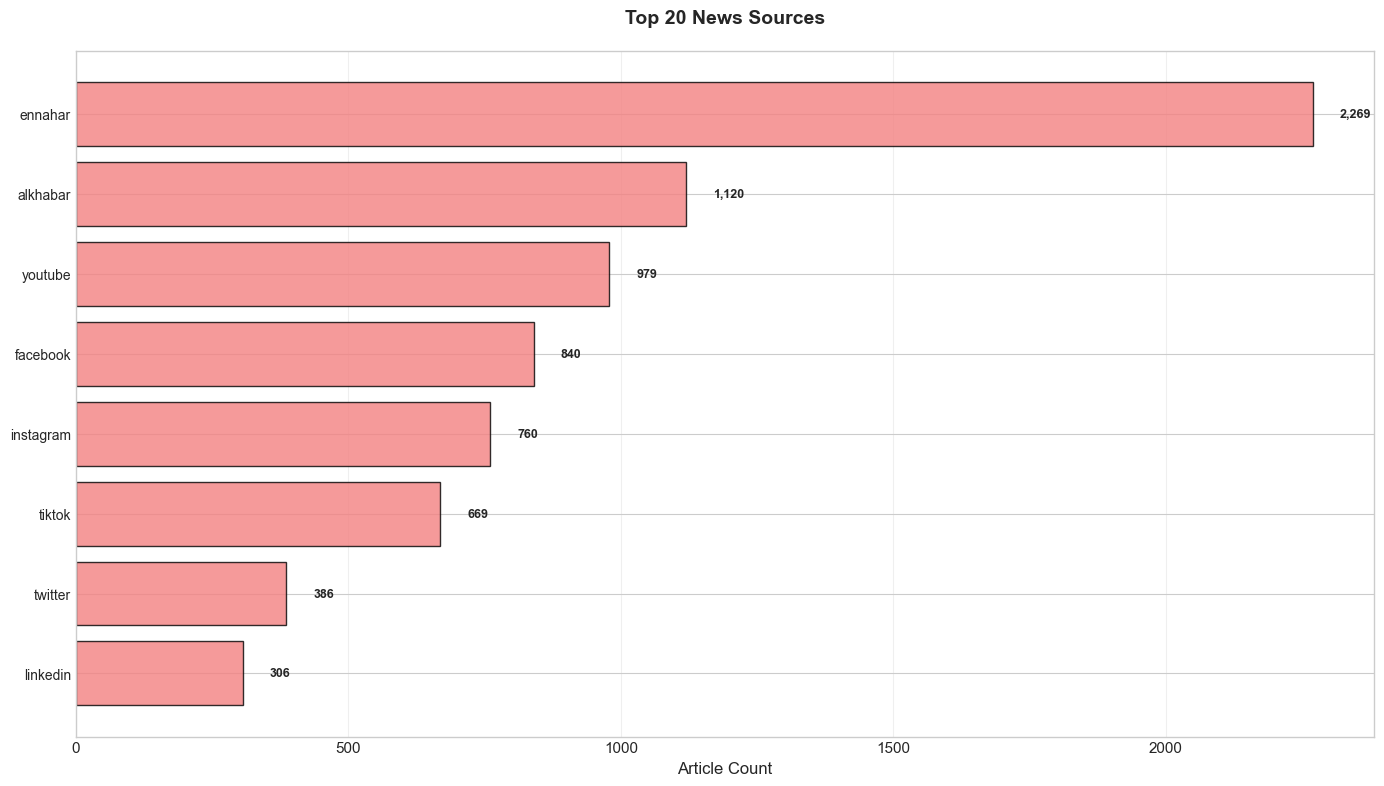

In [8]:
# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
top_sources = df['source'].value_counts().head(20)
bars = ax.barh(range(len(top_sources)), top_sources.values, 
               color='#F38181', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(top_sources)))
ax.set_yticklabels([s[:60] for s in top_sources.index], fontsize=10)
ax.set_xlabel('Article Count', fontsize=12)
ax.set_title('Top 20 News Sources', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2, 
           f'{int(width):,}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Category Analysis

In [9]:
print("="*80)
print("📑 CATEGORY ANALYSIS")
print("="*80)

unique_cats = df['category'].nunique()
print(f"\n📊 Total Unique Categories: {unique_cats:,}")

# Top categories
print("\n🏆 Top 15 Categories:")
top_cats = df['category'].value_counts().head(15)

print("\n┌────┬───────────────────────────────────┬──────────┬──────────┬─────────────────────┐")
print("│ #  │ Category                          │  Count   │    %     │ Distribution        │")
print("├────┼───────────────────────────────────┼──────────┼──────────┼─────────────────────┤")

for i, (cat, count) in enumerate(top_cats.items(), 1):
    pct = (count / len(df)) * 100
    bar = "█" * int(pct)
    cat_display = cat[:30] + "..." if len(cat) > 30 else cat
    print(f"│ {i:>2} │ {cat_display:<33} │ {count:>8,} │ {pct:>7.2f}% │ {bar:<19} │")

print("└────┴───────────────────────────────────┴──────────┴──────────┴─────────────────────┘")

# Category distribution per label
print("\n📊 Top Categories per Label:")

crosstab = pd.crosstab(
    df['category'],
    df['label'],
    normalize='columns'
) * 100

for label in df['label'].unique():
    label_name = label_names.get(label, str(label))

    print(f"\n🏷️  {label_name}:")
    
    top_cats_label = crosstab[label].nlargest(5)

    for cat, pct in top_cats_label.items():
        cat_display = cat[:40] + "..." if len(cat) > 40 else cat
        print(f"   • {cat_display:<43} {pct:>6.2f}%")

📑 CATEGORY ANALYSIS

📊 Total Unique Categories: 9

🏆 Top 15 Categories:

┌────┬───────────────────────────────────┬──────────┬──────────┬─────────────────────┐
│ #  │ Category                          │  Count   │    %     │ Distribution        │
├────┼───────────────────────────────────┼──────────┼──────────┼─────────────────────┤
│  1 │ nation                            │    1,774 │   24.21% │ ████████████████████████ │
│  2 │ economie                          │    1,104 │   15.06% │ ███████████████     │
│  3 │ monde                             │      934 │   12.74% │ ████████████        │
│  4 │ culture                           │      887 │   12.10% │ ████████████        │
│  5 │ sport                             │      812 │   11.08% │ ███████████         │
│  6 │ hightech                          │      618 │    8.43% │ ████████            │
│  7 │ sante                             │      550 │    7.50% │ ███████             │
│  8 │ islam                             │      419 

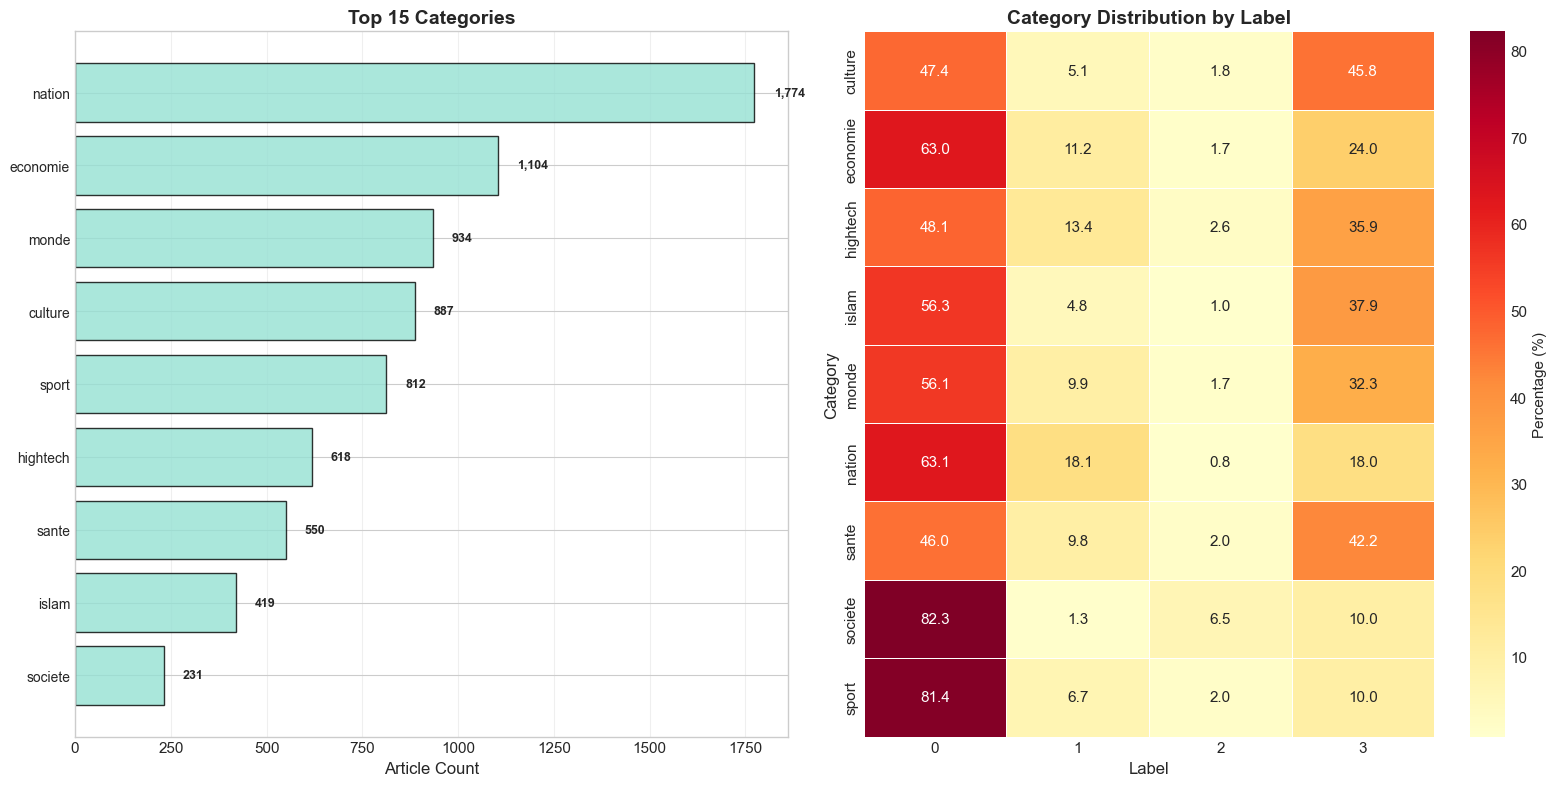

In [11]:
# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart
top_cats = df['category'].value_counts().head(15)
bars = ax1.barh(range(len(top_cats)), top_cats.values, 
               color='#95E1D3', alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(top_cats)))
ax1.set_yticklabels([c[:40] for c in top_cats.index], fontsize=10)
ax1.set_xlabel('Article Count', fontsize=12)
ax1.set_title('Top 15 Categories', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 50, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', ha='left', va='center', fontsize=9, fontweight='bold')

# Heatmap
top_cats_list = df['category'].value_counts().head(15).index
crosstab = pd.crosstab(df[df['category'].isin(top_cats_list)]['category'], 
                      df['label'], normalize='index') * 100
sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2, 
           cbar_kws={'label': 'Percentage (%)'}, linewidths=0.5)
ax2.set_title('Category Distribution by Label', fontsize=14, fontweight='bold')
ax2.set_xlabel('Label', fontsize=12)
ax2.set_ylabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

---
## 7. Temporal Analysis

In [12]:
print("="*80)
print("📅 TEMPORAL ANALYSIS")
print("="*80)

# Parse dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Date range
print("\n📆 Date Range:")
print(f"   Earliest: {df['date'].min()}")
print(f"   Latest:   {df['date'].max()}")
print(f"   Span:     {(df['date'].max() - df['date'].min()).days:,} days")

# By year
print("\n📊 Articles by Year:")
by_year = df['date'].dt.year.value_counts().sort_index()

print("\n┌────────┬──────────┬───────────────────────────────────────────────────┐")
print("│  Year  │  Count   │ Distribution                                      │")
print("├────────┼──────────┼───────────────────────────────────────────────────┤")

max_count = by_year.max()
for year, count in by_year.items():
    bar = "█" * int((count / max_count) * 50)
    print(f"│ {year:>6} │ {count:>8,} │ {bar:<50} │")

print("└────────┴──────────┴───────────────────────────────────────────────────┘")

📅 TEMPORAL ANALYSIS

📆 Date Range:
   Earliest: 2014-01-09 00:00:00
   Latest:   2025-11-16 00:00:00
   Span:     4,329 days

📊 Articles by Year:

┌────────┬──────────┬───────────────────────────────────────────────────┐
│  Year  │  Count   │ Distribution                                      │
├────────┼──────────┼───────────────────────────────────────────────────┤
│ 2014.0 │       29 │                                                    │
│ 2015.0 │       41 │                                                    │
│ 2016.0 │       31 │                                                    │
│ 2017.0 │       21 │                                                    │
│ 2018.0 │       25 │                                                    │
│ 2019.0 │       17 │                                                    │
│ 2020.0 │       24 │                                                    │
│ 2021.0 │       24 │                                                    │
│ 2022.0 │       59 │          

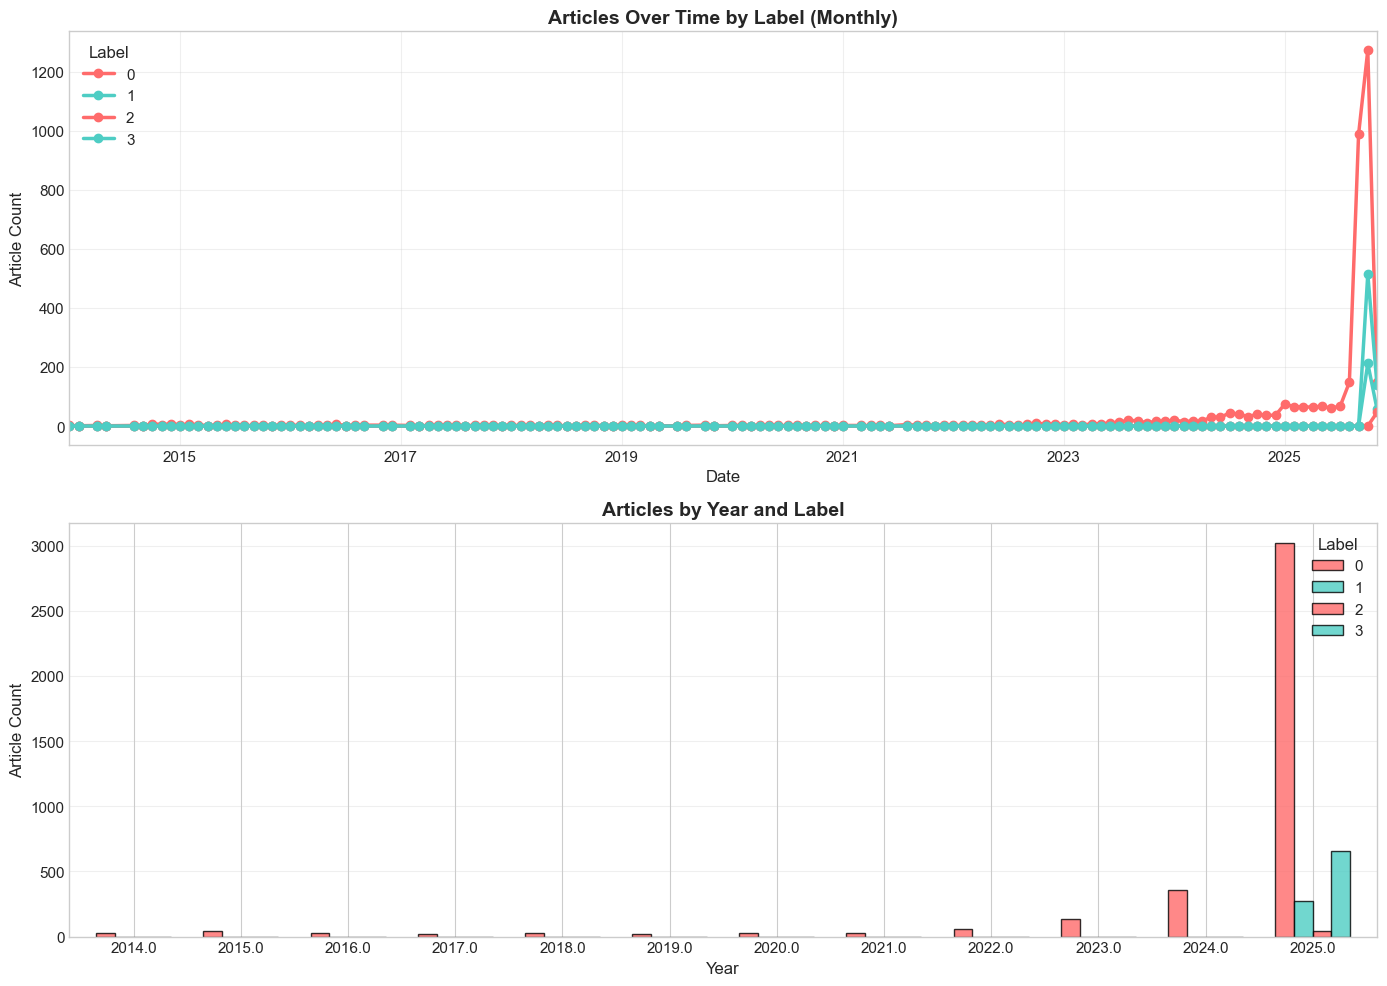

In [13]:
# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Monthly trends
monthly = df.groupby([df['date'].dt.to_period('M'), 'label']).size().unstack(fill_value=0)
colors = ['#FF6B6B', '#4ECDC4']
monthly.plot(ax=ax1, marker='o', linewidth=2.5, markersize=6, color=colors)
ax1.set_title('Articles Over Time by Label (Monthly)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Article Count', fontsize=12)
ax1.legend(title='Label', fontsize=11, title_fontsize=12)
ax1.grid(alpha=0.3)

# Yearly trends
yearly = df.groupby([df['date'].dt.year, 'label']).size().unstack(fill_value=0)
yearly.plot(kind='bar', ax=ax2, color=colors, alpha=0.8, edgecolor='black', width=0.7)
ax2.set_title('Articles by Year and Label', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Article Count', fontsize=12)
ax2.legend(title='Label', fontsize=11, title_fontsize=12)
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

---
## 8. Stylistic Analysis

In [21]:
print("="*80)
print("✍️  STYLISTIC ANALYSIS")
print("="*80)

def count_stylistic_features(text):
    text = str(text)
    return {
        'exclamation': text.count('!') + text.count('！'),       # also full-width exclamation
        'question': text.count('?') + text.count('؟'),           # Arabic question mark
        'ellipsis': text.count('...') + text.count('…'),
    }

print("\n🔄 Analyzing stylistic features...")
style_features = df['text'].progress_apply(count_stylistic_features).apply(pd.Series)

# Overall statistics
print("\n📊 Overall Stylistic Features:")
print("\n┌──────────────────────┬──────────┬──────────┐")
print("│      Feature         │   Mean   │  Median  │")
print("├──────────────────────┼──────────┼──────────┤")

for col in style_features.columns:
    mean_val = style_features[col].mean()
    median_val = style_features[col].median()
    feature_name = col.replace('_', ' ').title()
    print(f"│ {feature_name:<20} │ {mean_val:>8.2f} │ {median_val:>8.2f} │")

print("└──────────────────────┴──────────┴──────────┘")

print("\n📊 Comparison by Label:")

for label in df['label'].unique():
    label_name = label_names.get(label, str(label))
    
    label_df = df[df['label'] == label]
    label_style = label_df['text'] \
        .apply(count_stylistic_features) \
        .apply(pd.Series)

    print(f"\n🏷️  {label_name}:")

    for col in label_style.columns:
        mean_val = label_style[col].mean()
        feature_name = col.replace('_', ' ').title()
        print(f"   • {feature_name:<25} {mean_val:>8.2f}")

✍️  STYLISTIC ANALYSIS

🔄 Analyzing stylistic features...


100%|██████████| 7329/7329 [00:00<00:00, 301045.47it/s]



📊 Overall Stylistic Features:

┌──────────────────────┬──────────┬──────────┐
│      Feature         │   Mean   │  Median  │
├──────────────────────┼──────────┼──────────┤
│ Exclamation          │     0.14 │     0.00 │
│ Question             │     0.10 │     0.00 │
│ Ellipsis             │     0.08 │     0.00 │
└──────────────────────┴──────────┴──────────┘

📊 Comparison by Label:

🏷️  Not News:
   • Exclamation                   0.20
   • Question                      0.25
   • Ellipsis                      0.00

🏷️  Not Fake:
   • Exclamation                   0.08
   • Question                      0.03
   • Ellipsis                      0.14

🏷️  Fake:
   • Exclamation                   0.30
   • Question                      0.08
   • Ellipsis                      0.01

🏷️  Satire:
   • Exclamation                   0.23
   • Question                      0.20
   • Ellipsis                      0.00


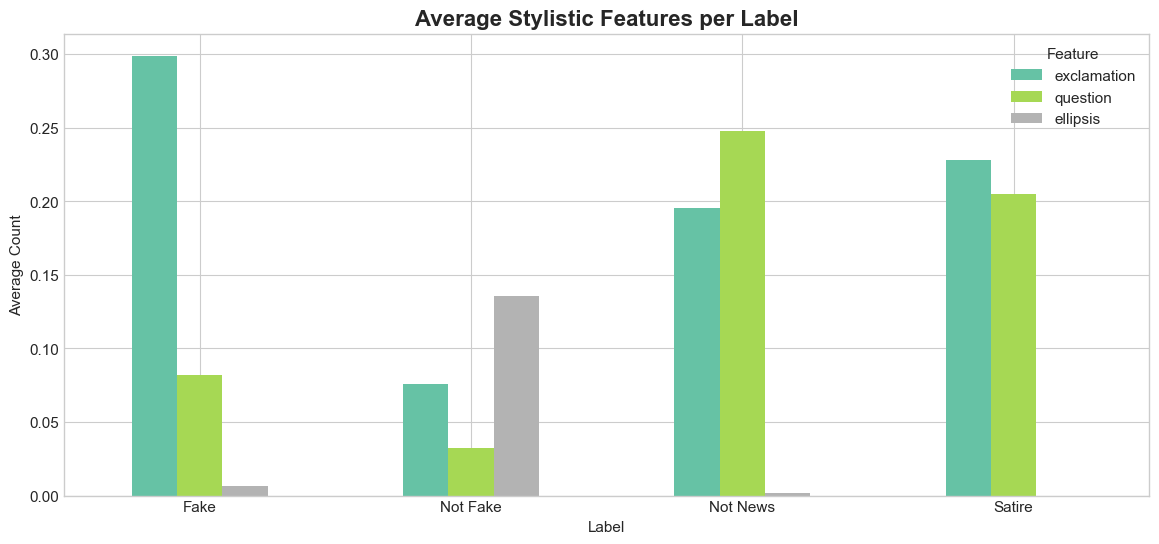

In [23]:

# ---------- Bar plot of mean features per label ----------
mean_features = style_features.groupby('label').mean()
mean_features.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Average Stylistic Features per Label', fontsize=16, fontweight='bold')
plt.ylabel('Average Count')
plt.xlabel('Label')
plt.xticks(rotation=0)
plt.legend(title='Feature')
plt.show()

---
## 9. Text Length Analysis

### 9.1 Character and Word Counts

In [27]:
print("="*80)
print("📏 TEXT LENGTH ANALYSIS")
print("="*80)

# Calculate lengths
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Overall statistics
print("\n📊 Overall Statistics:")
print("\nCharacter Length:")
print(df['text_length'].describe())

print("\nWord Count:")
print(df['word_count'].describe())

for label in df['label'].unique():
    label_df = df[df['label'] == label]
    label_name = label_names.get(label, str(label))  # map to name
    print(f"\n🏷️  {label_name}:")
    print(f"   Character Length - Mean: {label_df['text_length'].mean():.0f}, "
          f"Median: {label_df['text_length'].median():.0f}, "
          f"Std: {label_df['text_length'].std():.0f}")
    print(f"   Word Count      - Mean: {label_df['word_count'].mean():.0f}, "
          f"Median: {label_df['word_count'].median():.0f}, "
          f"Std: {label_df['word_count'].std():.0f}")
    
    # Show sample
    min_idx = label_df['word_count'].idxmin()
    max_idx = label_df['word_count'].idxmax()
    print(f"\n   Shortest ({label_df['word_count'].min()} words): {label_df.loc[min_idx, 'text'][:100]}...")
    print(f"   Longest  ({label_df['word_count'].max()} words): {label_df.loc[max_idx, 'text'][:100]}...")

📏 TEXT LENGTH ANALYSIS

📊 Overall Statistics:

Character Length:
count     7329.000000
mean       219.200710
std        463.079585
min          1.000000
25%         59.000000
50%         84.000000
75%        177.000000
max      12635.000000
Name: text_length, dtype: float64

Word Count:
count    7329.000000
mean       36.646609
std        70.538130
min         1.000000
25%        10.000000
50%        14.000000
75%        30.000000
max      1914.000000
Name: word_count, dtype: float64

🏷️  Not News:
   Character Length - Mean: 112, Median: 94, Std: 71
   Word Count      - Mean: 19, Median: 16, Std: 12

   Shortest (1 words): ق...
   Longest  (155 words): رانا نوضّفو مدير تسويق! المعهد الإنجليزي للغات والثقافة، اللي كاين في العاصمة، راه يحوس على مدير تسو...

🏷️  Not Fake:
   Character Length - Mean: 294, Median: 81, Std: 584
   Word Count      - Mean: 49, Median: 13, Std: 89

   Shortest (2 words): ميساج للمعلم....
   Longest  (1914 words): مورا كل سم مكتوب على حيط الشهداء، كاين حكاية تا

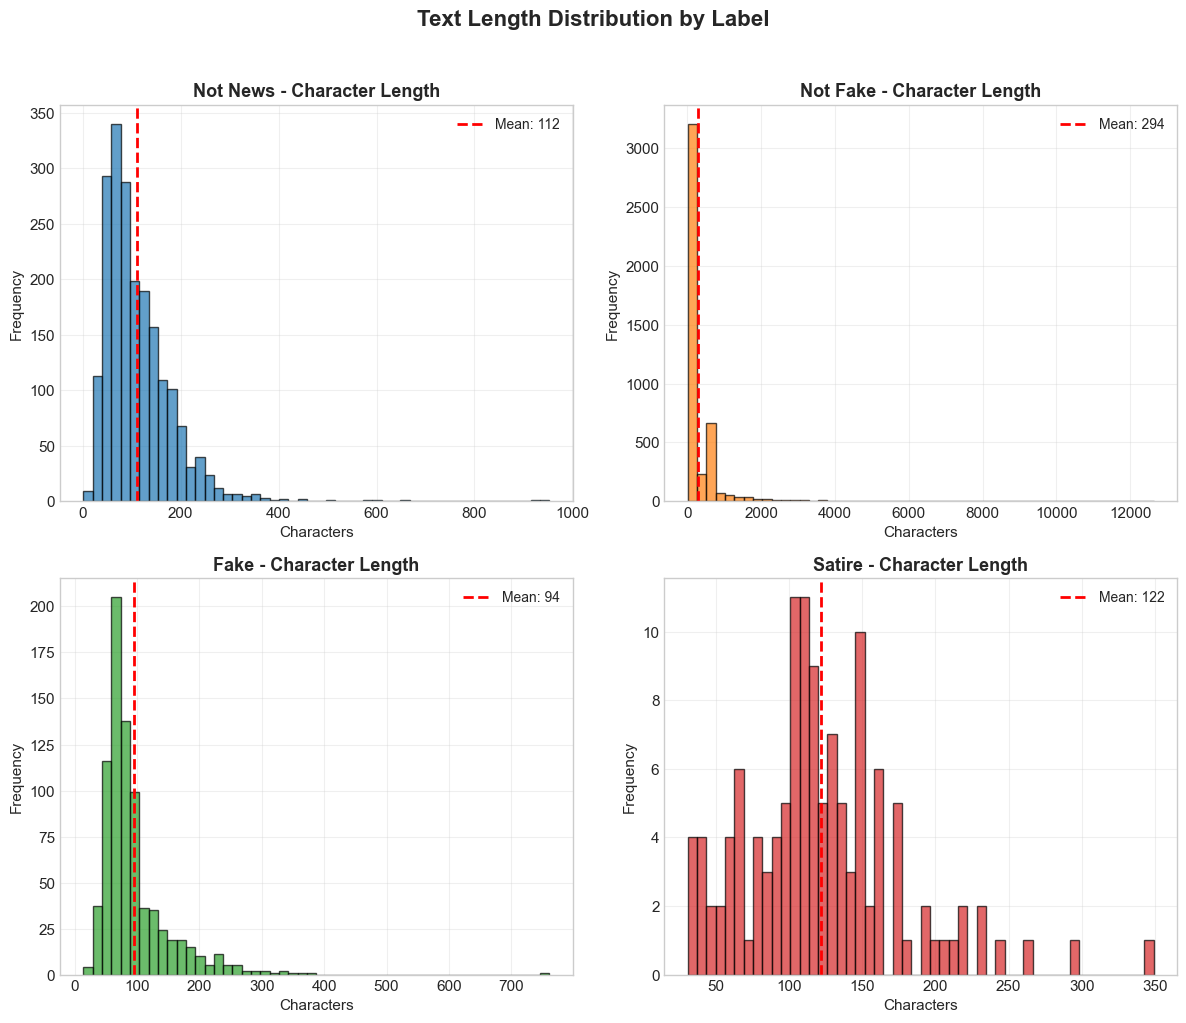

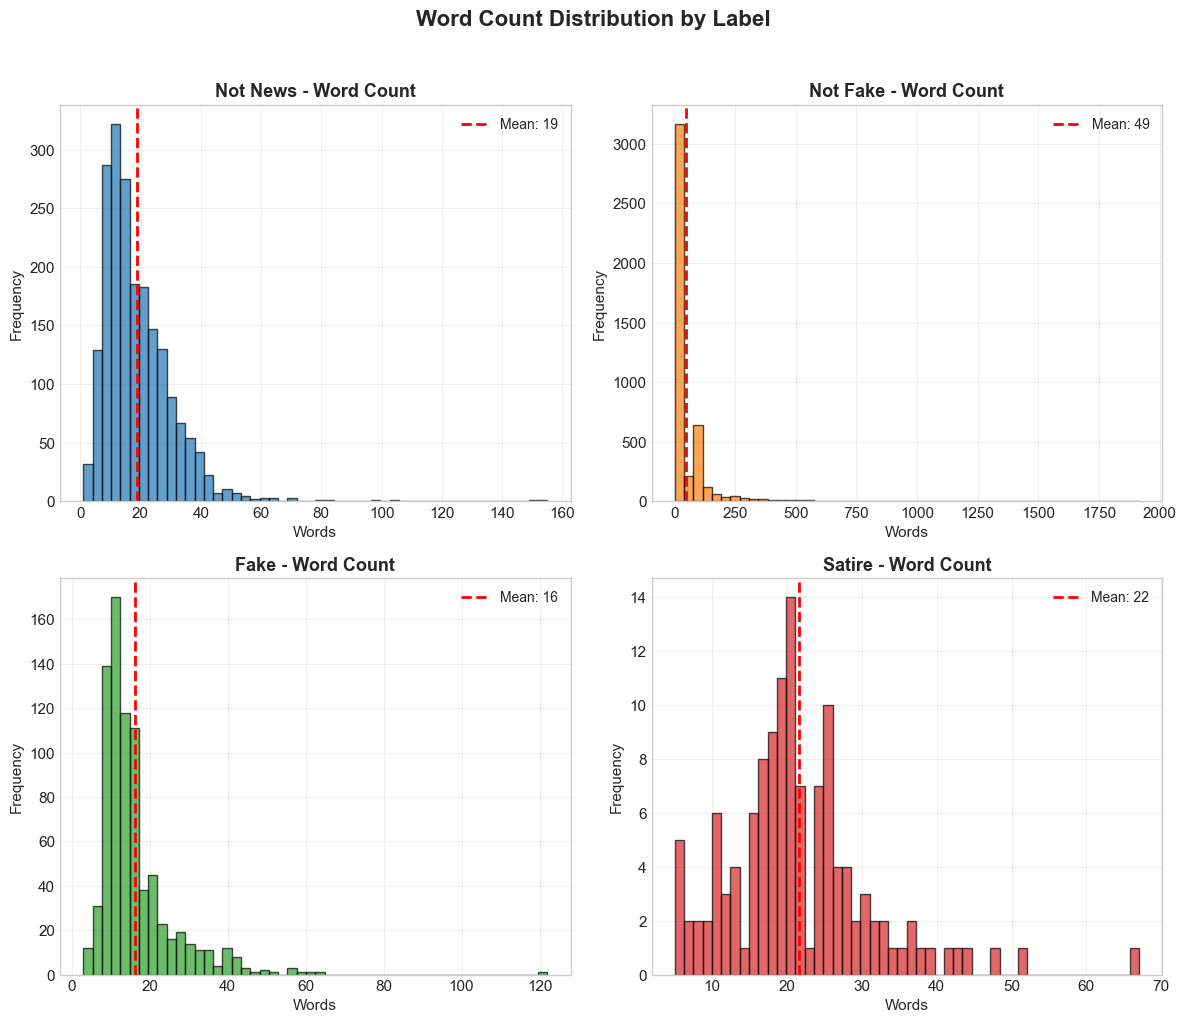

In [30]:
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------- Prepare labels ----------
labels = df['label'].unique()
n_labels = len(labels)
colors = cm.tab10.colors  # up to 10 distinct colors

# ---------- Create subplot grid dynamically ----------
rows = 2
cols = math.ceil(n_labels / rows)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5))
axes = axes.flatten()  # flatten in case of multiple rows/cols

# ---------- Plot histograms ----------
for i, label in enumerate(labels):
    label_df = df[df['label'] == label]
    color = colors[i % len(colors)]  # cycle through colors if more than 10 labels
    label_name = label_names.get(label, str(label))  # map numeric label to name

    # Character length histogram
    axes[i].hist(label_df['text_length'], bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{label_name} - Character Length', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Characters', fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].axvline(label_df['text_length'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Mean: {label_df['text_length'].mean():.0f}")
    axes[i].legend(fontsize=10)
    axes[i].grid(alpha=0.3)

plt.suptitle('Text Length Distribution by Label', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------- Word count histogram (separate figure) ----------
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5))
axes = axes.flatten()

for i, label in enumerate(labels):
    label_df = df[df['label'] == label]
    color = colors[i % len(colors)]
    label_name = label_names.get(label, str(label))

    axes[i].hist(label_df['word_count'], bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{label_name} - Word Count', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Words', fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].axvline(label_df['word_count'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Mean: {label_df['word_count'].mean():.0f}")
    axes[i].legend(fontsize=10)
    axes[i].grid(alpha=0.3)

plt.suptitle('Word Count Distribution by Label', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Token Length Analysis (with Tokenizer)

🔢 TOKEN LENGTH ANALYSIS

🔄 Tokenizing 1,000 texts...


Tokenizing: 100%|██████████| 1000/1000 [00:00<00:00, 4091.31it/s]



📊 Token Length Statistics:
   Min:        12
   Max:      5086
   Mean:   165.60
   Median:  72.00
   Std:    287.78

📍 Coverage Analysis (MAX_LENGTH=512):

┌─────────────┬──────────┬────────────┬────────┐
│ Percentile  │  Length  │  Coverage  │ Status │
├─────────────┼──────────┼────────────┼────────┤
│  50th       │       72 │     50.40%  │   ✓    │
│  75th       │      153 │     75.00%  │   ✓    │
│  90th       │      472 │     90.00%  │   ✓    │
│  95th       │      513 │     95.00%  │   ⚠️    │
│  99th       │     1283 │     99.00%  │   ⚠️    │
│ 100th       │     5086 │    100.00%  │   ⚠️    │
└─────────────┴──────────┴────────────┴────────┘

✅ 94.90% of texts fit within MAX_LENGTH=512
⚠️  51 texts (5.10%) will be truncated
📉 Average tokens lost per truncated text: 492


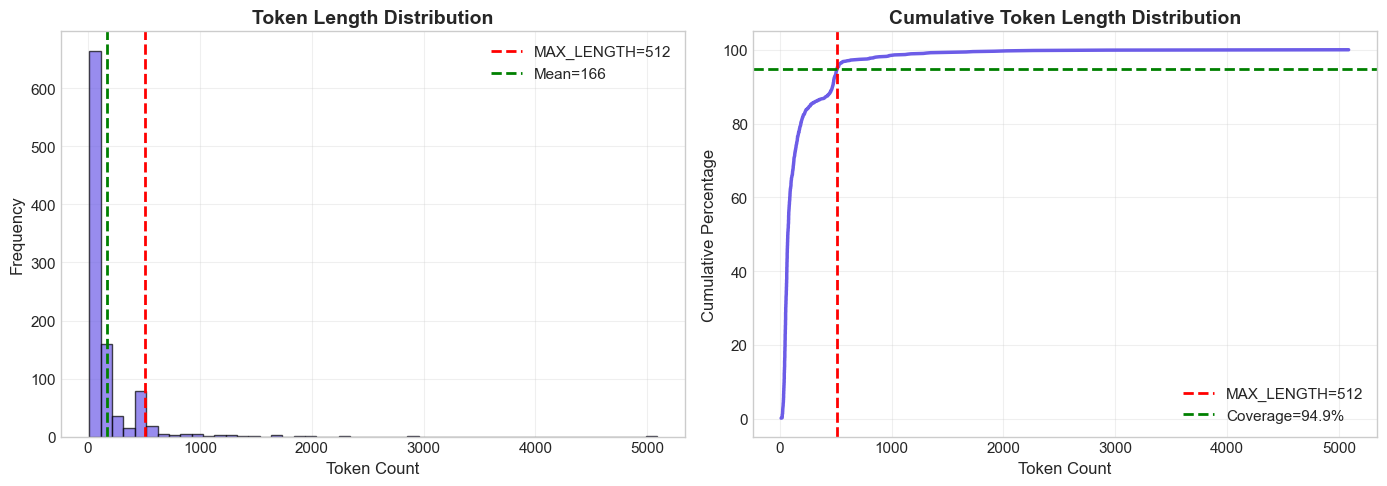

In [31]:
if TOKENIZER_AVAILABLE:
    print("="*80)
    print("🔢 TOKEN LENGTH ANALYSIS")
    print("="*80)
    
    # Sample texts for tokenization
    sample_size = min(1000, len(df))
    texts = df['text'].sample(sample_size, random_state=42).values
    
    # Tokenize
    print(f"\n🔄 Tokenizing {sample_size:,} texts...")
    token_lengths = []
    for text in tqdm(texts, desc="Tokenizing"):
        tokens = tokenizer.encode(str(text), add_special_tokens=True)
        token_lengths.append(len(tokens))
    token_lengths = np.array(token_lengths)
    
    # Statistics
    print("\n📊 Token Length Statistics:")
    print(f"   Min:    {token_lengths.min():>6}")
    print(f"   Max:    {token_lengths.max():>6}")
    print(f"   Mean:   {token_lengths.mean():>6.2f}")
    print(f"   Median: {np.median(token_lengths):>6.2f}")
    print(f"   Std:    {token_lengths.std():>6.2f}")
    
    # Coverage analysis
    max_length = 512  # Standard BERT max length
    print(f"\n📍 Coverage Analysis (MAX_LENGTH={max_length}):")
    print("\n┌─────────────┬──────────┬────────────┬────────┐")
    print("│ Percentile  │  Length  │  Coverage  │ Status │")
    print("├─────────────┼──────────┼────────────┼────────┤")
    
    percentiles = [50, 75, 90, 95, 99, 100]
    for p in percentiles:
        length = np.percentile(token_lengths, p)
        coverage = (token_lengths <= length).sum() / len(token_lengths) * 100
        status = "✓" if length <= max_length else "⚠️"
        print(f"│ {p:>3}th       │ {length:>8.0f} │ {coverage:>9.2f}%  │   {status}    │")
    
    print("└─────────────┴──────────┴────────────┴────────┘")
    
    coverage = (token_lengths <= max_length).sum() / len(token_lengths) * 100
    truncated = (token_lengths > max_length).sum()
    
    print(f"\n✅ {coverage:.2f}% of texts fit within MAX_LENGTH={max_length}")
    print(f"⚠️  {truncated:,} texts ({100-coverage:.2f}%) will be truncated")
    
    if truncated > 0:
        avg_trunc = token_lengths[token_lengths > max_length].mean()
        print(f"📉 Average tokens lost per truncated text: {avg_trunc - max_length:.0f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(token_lengths, bins=50, color='#6C5CE7', alpha=0.7, edgecolor='black')
    axes[0].axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'MAX_LENGTH={max_length}')
    axes[0].axvline(token_lengths.mean(), color='green', linestyle='--', linewidth=2, 
                   label=f'Mean={token_lengths.mean():.0f}')
    axes[0].set_title('Token Length Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Token Count', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)
    
    # Cumulative distribution
    sorted_lengths = np.sort(token_lengths)
    cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
    axes[1].plot(sorted_lengths, cumulative, linewidth=2.5, color='#6C5CE7')
    axes[1].axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'MAX_LENGTH={max_length}')
    axes[1].axhline(coverage, color='green', linestyle='--', linewidth=2, 
                   label=f'Coverage={coverage:.1f}%')
    axes[1].set_title('Cumulative Token Length Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Token Count', fontsize=12)
    axes[1].set_ylabel('Cumulative Percentage', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  Tokenizer not available. Skipping token analysis.")

---
## 10. Vocabulary and lexical diversity 

### 10.1 Vocabulary & Lexical Diversity Per Class

In [39]:
import numpy as np

def vocabulary_analysis(df, label_names=None):
    """Vocabulary and Lexical Diversity Analysis Per Class"""
    
    def get_vocabulary_stats(texts):
        all_words = []
        for text in texts:
            words = str(text).lower().split()
            all_words.extend(words)

        vocab_size = len(set(all_words))
        total_words = len(all_words)
        lexical_diversity = vocab_size / total_words if total_words > 0 else 0
        avg_word_length = np.mean([len(w) for w in all_words]) if total_words > 0 else 0

        return {
            'vocabulary_size': vocab_size,
            'total_words': total_words,
            'lexical_diversity': lexical_diversity,
            'avg_word_length': avg_word_length
        }

    vocab_stats = {
        'overall': get_vocabulary_stats(df['text']),
        'by_label': {}
    }

    for label in df['label'].unique():
        label_texts = df[df['label'] == label]['text']
        label_name = label_names.get(label, str(label)) if label_names else str(label)
        vocab_stats['by_label'][label_name] = get_vocabulary_stats(label_texts)

    # ---------- Print results ----------
    print("\n=== VOCABULARY AND LEXICAL DIVERSITY ===\n")

    overall = vocab_stats['overall']
    print("Overall:")
    print(f"  Vocabulary size      : {overall['vocabulary_size']}")
    print(f"  Total words          : {overall['total_words']}")
    print(f"  Lexical diversity    : {overall['lexical_diversity']:.3f}")
    print(f"  Average word length  : {overall['avg_word_length']:.2f}\n")

    for label, stats in vocab_stats['by_label'].items():
        print(f"Label {label}:")
        print(f"  Vocabulary size      : {stats['vocabulary_size']}")
        print(f"  Total words          : {stats['total_words']}")
        print(f"  Lexical diversity    : {stats['lexical_diversity']:.3f}")
        print(f"  Average word length  : {stats['avg_word_length']:.2f}\n")

    return vocab_stats

# Run the analysis
vocab_stats = vocabulary_analysis(df, label_names=label_names)


=== VOCABULARY AND LEXICAL DIVERSITY ===

Overall:
  Vocabulary size      : 54427
  Total words          : 268583
  Lexical diversity    : 0.203
  Average word length  : 4.92

Label Not News:
  Vocabulary size      : 13085
  Total words          : 37869
  Lexical diversity    : 0.346
  Average word length  : 4.97

Label Not Fake:
  Vocabulary size      : 46223
  Total words          : 215068
  Lexical diversity    : 0.215
  Average word length  : 4.91

Label Fake:
  Vocabulary size      : 5491
  Total words          : 12902
  Lexical diversity    : 0.426
  Average word length  : 4.86

Label Satire:
  Vocabulary size      : 1634
  Total words          : 2744
  Lexical diversity    : 0.595
  Average word length  : 4.70



### 10.2 Cross-Class Word Comparison

In [40]:
from itertools import combinations

# Collect words per label
words_by_label = {
    label_names.get(label, str(label)): set(" ".join(df[df['label']==label]['text'].astype(str)).lower().split())
    for label in df['label'].unique()
}

print("\n=== CROSS-CLASS WORD COMPARISON ===\n")

# Unique words per label
for label, words in words_by_label.items():
    other_words = set().union(*[w for l, w in words_by_label.items() if l != label])
    unique_words = words - other_words
    print(f"Label {label} has {len(unique_words)} unique words")

# Shared words and Jaccard similarity
print("\nJaccard Similarity Between Labels:")
for a, b in combinations(words_by_label.keys(), 2):
    shared = words_by_label[a] & words_by_label[b]
    jaccard = len(shared) / len(words_by_label[a] | words_by_label[b])
    print(f"{a} & {b} -> shared words: {len(shared)}, Jaccard: {jaccard:.3f}")


=== CROSS-CLASS WORD COMPARISON ===

Label Not News has 5827 unique words
Label Not Fake has 37686 unique words
Label Fake has 1530 unique words
Label Satire has 429 unique words

Jaccard Similarity Between Labels:
Not News & Not Fake -> shared words: 6862, Jaccard: 0.131
Not News & Fake -> shared words: 2486, Jaccard: 0.155
Not News & Satire -> shared words: 915, Jaccard: 0.066
Not Fake & Fake -> shared words: 3633, Jaccard: 0.076
Not Fake & Satire -> shared words: 1075, Jaccard: 0.023
Fake & Satire -> shared words: 602, Jaccard: 0.092


---


### Analysis : 
--- 

> The dataset has moderate overall diversity. Average word length is typical (~5 characters).

---

####  Per-Label Lexical Diversity

| Label       | Vocabulary Size | Total Words | Lexical Diversity | Avg Word Length |
|------------|----------------|------------|-----------------|----------------|
| Not News   | 13,085          | 37,869     | 0.346           | 4.97           |
| Not Fake   | 46,223          | 215,068    | 0.215           | 4.91           |
| Fake       | 5,491           | 12,902     | 0.426           | 4.86           |
| Satire     | 1,634           | 2,744      | 0.595           | 4.70           |

**Insights:**  
- Satire has the **highest diversity** (0.595) with a small vocabulary → specialized content.  
- Fake also has high diversity (0.426) in short texts.  
- Not Fake has the **largest vocabulary** but lower diversity (0.215) → repeated words.  
- Not News shows moderate diversity (0.346).

---

####  Cross-Class Word Comparison

##### Unique Words per Label
- **Not News:** 5,827  
- **Not Fake:** 37,686  
- **Fake:** 1,530  
- **Satire:** 429  

> Not Fake dominates in absolute unique words. Satire and Fake have few but distinct words.

##### Jaccard Similarity Between Labels

| Label Pair         | Shared Words | Jaccard Similarity |
|-------------------|-------------|------------------|
| Not News & Not Fake | 6,862       | 0.131            |
| Not News & Fake     | 2,486       | 0.155            |
| Not News & Satire   | 915         | 0.066            |
| Not Fake & Fake     | 3,633       | 0.076            |
| Not Fake & Satire   | 1,075       | 0.023            |
| Fake & Satire       | 602         | 0.092            |

**Observations:**  
- Not Fake & Satire are almost completely distinct (Jaccard = 0.023).  
- Not News & Fake overlap the most but still largely different (0.155).  
- Fake & Satire share some words (0.092) but remain mostly separate.

---

#### Key Takeaways
1. **Lexical richness:**  
   - Satire and Fake: high diversity in short, specialized texts.  
   - Not Fake: huge vocabulary, lower relative diversity.  

2. **Distinctive words:**  
   - Satire and Fake contain highly class-specific words.  
   - Not Fake overlaps moderately with Not News.  

3. **Implications for classification:**  
   - Unique words and low Jaccard similarity suggest lexical features can **effectively distinguish Satire and Fake** from other classes.  
   - TF-IDF or embeddings would capture these patterns efficiently.